# 02 – Run a 2D thermal simulation

Equivalent to `run_2D_clean.ipynb`, but using the generic `PIC` module.
Supports `NoMaxwell`, `SpectralMaxwell`, and `SBPMaxwell`.

In [ ]:
using Pkg
const PROJECT_DIR = abspath(get(ENV, "PIC_PROJECT_DIR", normpath(joinpath(pwd(), ".."))))
isdir(joinpath(PROJECT_DIR, "src")) || error("PIC_PROJECT_DIR must point to the PIC_refactor project: $PROJECT_DIR")
Pkg.activate(PROJECT_DIR)
Pkg.instantiate()


  Activating new project at `/home`


LoadError: SystemError: opening file "/home/Manifest.toml": Permission denied

In [ ]:
cd(PROJECT_DIR)
include(joinpath(PROJECT_DIR, "src", "PIC.jl"))
using .PIC
using Plots
using Statistics
using Base.Threads
using Printf
using FileIO, JLD2
using SummationByPartsOperators
println("project_dir = ", PROJECT_DIR)
println("nthreads = ", nthreads())


LoadError: SystemError: opening file "/home/src/PIC.jl": No such file or directory

## Setup grid and load initial data

In [ ]:
# Run parameters
const N_exp = 5
const N = 10^N_exp
const order = 5
const factor = 2

J = (50, 50)
box = Box((0.0, 1.0, 0.0, 1.0))
g = PICGrid(box, J, order)

nm = [1, 1]
alpha_exp = 1
θ_exp = 3
θ = 10.0^(-θ_exp)

data_name = "par_dis_rel_thermal_nm_[$(nm[1]),$(nm[2])]_alp$(alpha_exp)_N$(N_exp)_Th$(θ_exp)"
file_name = joinpath(PROJECT_DIR, "Initial_Distributions", data_name * ".jld2")

par_dis, run_name, pars, par_f_x, box_x, par_f_p, box_p = retrieve_initial_data_D(file_name)

# Evolution parameters
t_i = 0.0
t_f = 0.10
M = 11
M_g = 10
dt = (t_f - t_i) / (M - 1)
dx = differentials(g)
@show dt, minimum(dx), dt / minimum(dx)


(dt, minimum(dx), dt / minimum(dx)) = (0.01, 0.02, 0.5)


(0.01, 0.02, 0.5)

## Build state vector, deposit density, solve Poisson

coordinate test passed
initial  max |div E + rho| = 2.2656345785658075e-15
initial  L2  |div E + rho| = 1.5959450139752753e-15


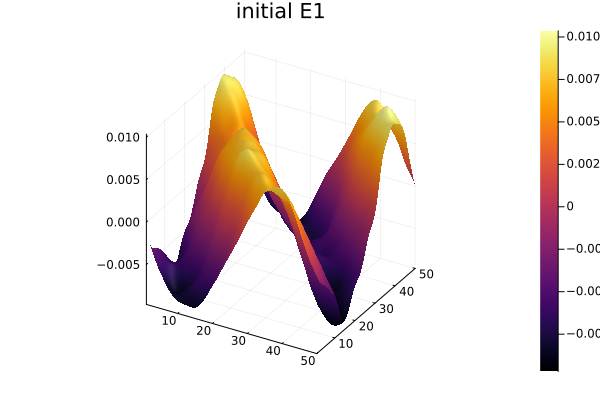

In [ ]:
u = make_state(g, N)
u[1:4N] .= par_dis

n = zeros(size(g))
dep = DepositDensity(g, N)
deposit!(dep, u, g, n; factor=factor)
rho = n .- 1.0

E = zeros(2, size(g)...)
solve_poisson!(E, rho, g)
B = zeros(size(g))
set_fields!(u, g, N, E, B)
coordinate_test(u, g, N)

err_max_initial, err_l2_initial = check_constraints(u, g, N, dep, factor)
println("initial  max |div E + rho| = ", err_max_initial)
println("initial  L2  |div E + rho| = ", err_l2_initial)

surface(E[1,:,:], title="initial E1")


## Choose Maxwell solver and prepare evolution

In [ ]:
# Choose one of the three Maxwell solvers:
#   1. NoMaxwell{2}()          -> electrostatic (B not evolved)
#   2. SpectralMaxwell(g)      -> periodic spectral derivatives
#   3. SBPMaxwell((Dx, Dy))    -> summation-by-parts finite differences

derivative_order = 1
accuracy_order = 6
solver_choice = :sbp   # <-- change to :no_maxwell, :spectral, or :sbp

if solver_choice == :no_maxwell
    maxwell = NoMaxwell{2}()
    suffix = "no_maxwell"
elseif solver_choice == :spectral
    maxwell = SpectralMaxwell(g)
    suffix = "spectral"
elseif solver_choice == :sbp
    Dx = periodic_derivative_operator(derivative_order=derivative_order, accuracy_order=accuracy_order,
                                      xmin=box.lo[1], xmax=box.hi[1], N=J[1])
    Dy = periodic_derivative_operator(derivative_order=derivative_order, accuracy_order=accuracy_order,
                                      xmin=box.lo[2], xmax=box.hi[2], N=J[2])
    maxwell = SBPMaxwell((Dx, Dy))
    suffix = "sbp"
else
    error("unknown solver_choice = $solver_choice")
end

p = RHSParams(g, N; factor=factor, maxwell=maxwell)
ws = StepWorkspace(u)

run_name_full = "thermal_rel_$(suffix)_J$(J[1])x$(J[2])_N$(N_exp)_Th$(θ_exp)_alp$(alpha_exp)_o$(order)"
out_file = joinpath(PROJECT_DIR, "Results", run_name_full * ".jld2")
mkpath(dirname(out_file))
isfile(out_file) && rm(out_file)

println("Running with solver: ", solver_choice)
println("Output: ", out_file)

err_max, err_l2 = check_constraints(u,g,N,dep, factor)


Running with solver: sbp
Output: ../Results/thermal_rel_sbp_J50x50_N5_Th3_alp1_o5.jld2


(2.2656345785658075e-15, 1.5959450139752753e-15)

## Time integration with RK4

In [ ]:
# save metadata
save(out_file, Dict(
    "run_name" => run_name_full,
    "par_grid" => (N, J, box, order),
    "par_evolv" => (t_i, t_f, M, M_g, dt)
))

# initial averages
save_averages(out_file, 1, u, g, N; dep=dep, factor=factor)

let t = t_i
    out_every = div(M - 1, M_g - 1)
    for k in 2:M
        RK4_step!(rhs!, u, t, dt, p; ws=ws)
        t += dt
        if (k - 1) % out_every == 0
            j = (k - 1) ÷ out_every + 1
            save_averages(out_file, j, u, g, N; dep=dep, factor=factor)
            EK, EE = total_energy(u, g, N)
            err_max, err_l2 = check_constraints(u, g, N, dep, factor)
            println("j = ", j, "  t = ", round(t, digits=3), "  E_total = ", EK + EE, " conts_max = ", err_max, " conts_L2 = ", err_l2)
        end
    end
end

err_max_final, err_l2_final = check_constraints(u, g, N, dep, factor)
println("final    max |div E - rho| = ", err_max_final)
println("final    L2  |div E - rho| = ", err_l2_final)
println("Done. Output: ", out_file)


j = 2  t = 0.01  E_total = 0.0010274128670858507 conts_max = 2.5767125147965405e-5 conts_L2 = 1.911126614940674e-5
j = 3  t = 0.02  E_total = 0.0010274128670542755 conts_max = 6.036044050202956e-5 conts_L2 = 4.762553410689209e-5
j = 4  t = 0.03  E_total = 0.0010274128670227265 conts_max = 0.00010658949331666063 conts_L2 = 8.026311868619046e-5
j = 5  t = 0.04  E_total = 0.0010274128669911736 conts_max = 0.0001492393592092135 conts_L2 = 0.00011029054585751441
j = 6  t = 0.05  E_total = 0.001027412866959683 conts_max = 0.00017884456823603938 conts_L2 = 0.00013623501319850244
j = 7  t = 0.06  E_total = 0.001027412866928225 conts_max = 0.00019775658915945776 conts_L2 = 0.00015790193749744833
j = 8  t = 0.07  E_total = 0.0010274128668968125 conts_max = 0.00021540693205103657 conts_L2 = 0.00017434504046260802
j = 9  t = 0.08  E_total = 0.001027412866865445 conts_max = 0.00024025976389780392 conts_L2 = 0.00018812241910518907
j = 10  t = 0.09  E_total = 0.0010274128668341335 conts_max = 0.00027

## Final density snapshot

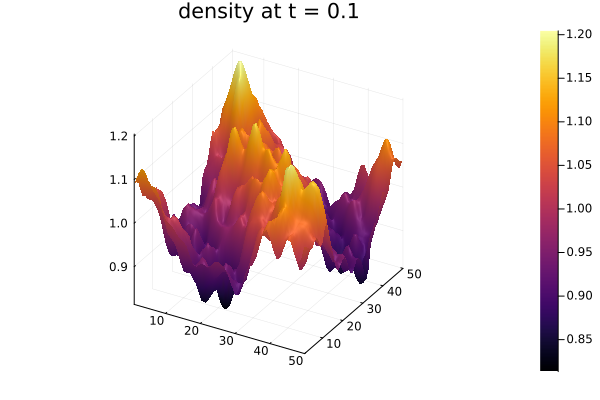

In [ ]:
# final density snapshot at the last saved time
deposit!(dep, u, g, n; factor=factor)
surface(n, title="density at t = $(t_f)")


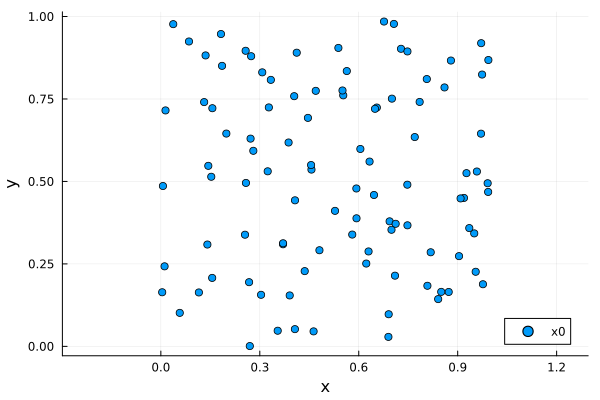

In [ ]:
p = 4
r0_frac = 0.1
N_test = 100
x0 = [box.lo .+ rand(length(box)) .* extent(box) for _ in 1:N_test]
scatter([x[1] for x in x0], [x[2] for x in x0], xlabel="x", ylabel="y", label="x0", aspect_ratio=:equal)


In [ ]:
# save the relative error
weak_checks = [check_constraints_weak(u, g, N, dep, factor, x, r0_frac, p)[3] for x in x0]
@show sum(weak_checks)/length(weak_checks)

sum(weak_checks) / length(weak_checks) = 0.00013848266759819037


0.00013848266759819037